In [1]:
!pip install numpy pandas matplotlib

  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-macosx_10_9_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (9.9 MB)
Using cached matplotlib-3.11.0-cp311-cp311-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using ca

Shape: (3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68



Dtypes:
Country                                    str
Year                                     int64
Attack Type                                str
Target Industry                            str
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                              str
Security Vulnerability Type                str
Defense Mechanism Used                     str
Incident Resolution Time (in Hours)      int64
dtype: object

NaN por coluna:
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000



Value counts: Country


...

Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64


Value counts: Security Vulnerability Type


Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64


Value counts: Defense Mechanism Used


Defense Mechanism Used
Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: count, dtype: int64

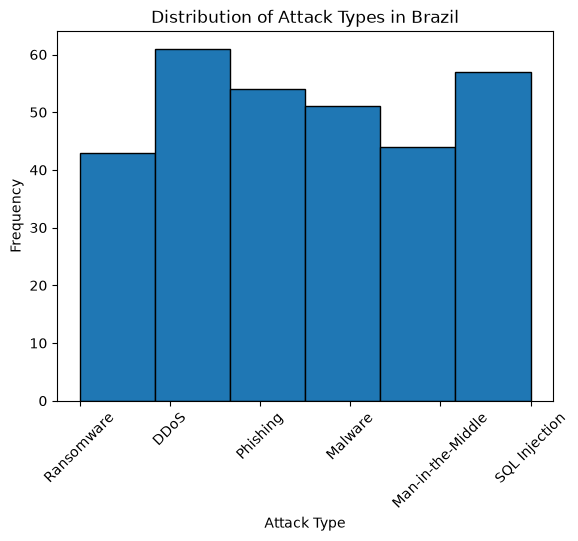

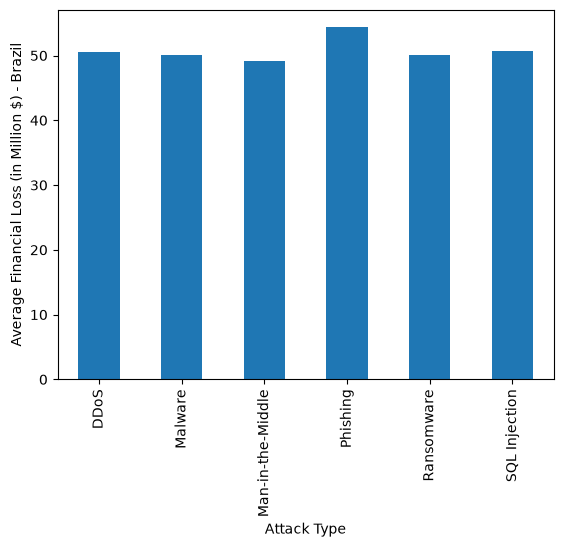

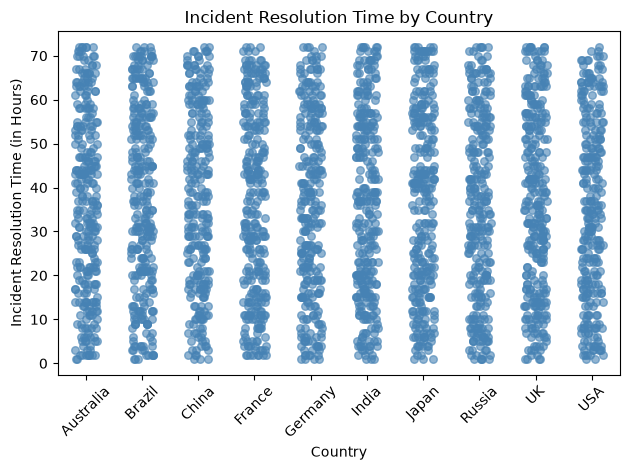

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
display(df.head())
print("\nDtypes:")
print(df.dtypes)

print("\nNaN por coluna:")
print(df.isna().sum())

display(df.select_dtypes(include="number").describe())

cat_cols = df.select_dtypes(exclude="number").columns.tolist()
if len(cat_cols) > 0:
    for c in cat_cols:
        print(f"\nValue counts: {c}")
        display(df[c].value_counts().head(10))


df_brazil = df[df["Country"] == "Brazil"]
plt.figure()
plt.hist(df_brazil["Attack Type"], bins=6, edgecolor="black")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.title("Distribution of Attack Types in Brazil")
plt.xticks(rotation=45)
plt.show()

plt.figure()
df_brazil.groupby("Attack Type")["Financial Loss (in Million $)"].mean().plot(kind="bar")
plt.xlabel("Attack Type")
plt.ylabel("Average Financial Loss (in Million $) - Brazil")
plt.show()

np.random.seed(100)

countries = df["Country"].astype("category")
x = countries.cat.codes + np.random.uniform(-0.2, 0.2, size=len(df))
y = df["Incident Resolution Time (in Hours)"]

plt.scatter(x, y, alpha=0.6, s=30, color="steelblue")

ticks = np.arange(len(countries.cat.categories))
labels = countries.cat.categories

plt.xticks(ticks, labels, rotation=45)
plt.xlabel("Country")
plt.ylabel("Incident Resolution Time (in Hours)")
plt.title("Incident Resolution Time by Country")
plt.xlim(-0.5, len(countries.cat.categories) - 0.5)
plt.tight_layout()
plt.show()



# Insights — EDA Incidentes de Cibersegurança

**Insight 1 (padrão):**
No Brasil, o ataque mais comum foi DDoS (61 casos), seguido de SQL Injection (57) e Phishing (54). Mas quando olho a perda financeira média por tipo de ataque globalmente, todos ficam entre 49 e 52 milhões de dólares — praticamente empatados. Não dá pra dizer que um tipo de ataque é mais caro que outro, o que foi meio inesperado.

**Insight 2 (qualidade de dados):**
O dataset não tem nenhum NaN em nenhuma coluna, e os números parecem distribuídos demais — a perda financeira vai de 0.5 a 99.99 com média quase exata de 50, e o tempo de resolução é praticamente igual em todos os países. Minha suspeita é que esse dataset é sintético, então conclusões muito fortes sobre o mundo real seriam forçadas.

**Insight 3 (hipótese/modelo futuro):**
Daria pra tentar prever o tempo de resolução do incidente (`Incident Resolution Time`) com as outras colunas — seria uma regressão. O problema é que as correlações numéricas são quase zero, então provavelmente precisaria usar as colunas categóricas (tipo de defesa, fonte do ataque) com algum encoding pra ver se aparece algum padrão.